<a href="https://colab.research.google.com/github/andrigerber/Adv_GenAI/blob/main/Step_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 3. Evaluation

**Advanced Generative AI**  
**Semester Project**

- **Supervisor:** Dr. Guang Lu  
- **Students:** Andri Gerber · Amir Shatrolli · Kened Kqiraj

---

<h1 style="font-size:2.7em; margin-bottom:0.5em;">Author Contributions</h1>
<table style="
  width: 100%;
  border-collapse: collapse;
  font-family: 'Segoe UI', Arial, sans-serif;
  font-size: 2em;
  ">
  <thead>
    <tr>
      <th style="
        border-bottom: 4px solid #222;
        text-align: left;
        padding: 28px 20px 20px 20px;
        background-color: #f7f7f7;
        font-size: 1.25em;
        letter-spacing: 0.02em;
        ">Name</th>
      <th style="
        border-bottom: 4px solid #222;
        text-align: left;
        padding: 28px 20px 20px 20px;
        background-color: #f7f7f7;
        font-size: 1.25em;
        letter-spacing: 0.02em;
        ">Contribution Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Andri Gerber</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Developed the codebase, prepared the documentation/report.</td>
    </tr>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Kened Kqiraj</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Reviewed the code and report, and provided feedback.</td>
    </tr>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Amir Shatrolli</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Reviewed the code and report, and provided feedback.</td>
    </tr>
  </tbody>
</table>

---



# General Overview

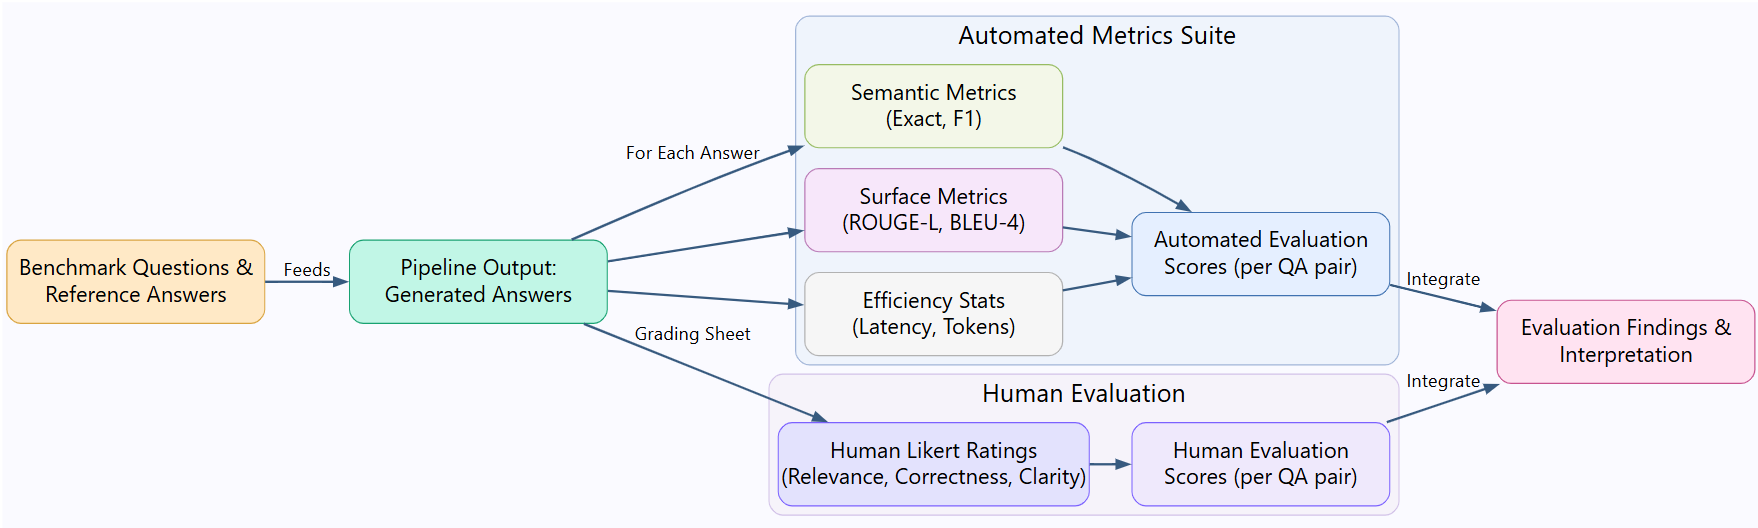

## Table of Contents

<div style="font-size:1.3em; line-height:1.7;">
<b>1. Abstract</b><br>
<b>2. Automated Answer Quality Evaluation</b><br>
&nbsp;&nbsp;2.1 Pipeline Setup and Model Loading<br>
&nbsp;&nbsp;2.2 Generation and Caching of System Answers<br>
&nbsp;&nbsp;2.3 Reference Answer Integration<br>
&nbsp;&nbsp;2.4 Automated Metric Suite (Semantic, ROUGE, BLEU)<br>
&nbsp;&nbsp;2.5 Quantitative Results<br>
<b>3. Human Evaluation Protocol</b><br>
&nbsp;&nbsp;3.1 CSV Sheet Generation for Human Grading<br>
&nbsp;&nbsp;3.2 Guidelines for Relevance, Correctness, Clarity<br>
<b>4. Latency and Efficiency</b><br>
<b>5. Discussion and Next Steps</b><br>
<b>6. References</b>
</div>


## Abstract

In the final Step, we conduct a comprehensive evaluation of answer quality produced by our end-to-end RAG pipeline. We systematically benchmark our best-performing reranking and answer generation setup (Cohere + GPT-4o) using both automated and human-centric metrics. Automated evaluation leverages a diverse suite of metrics—including semantic similarity (embedding-based exact and F1), ROUGE-L, and BLEU-4—against high-quality bilingual reference answers, providing fine-grained insight into factual overlap and linguistic adequacy. Latency, token usage, and other efficiency measures are tracked for practical assessment.

To complement automated scores, we generate a structured template for human evaluation, enabling graders to rate answer relevance, correctness, and clarity using standardized rubrics. Our analysis integrates quantitative results with efficiency considerations, enabling a holistic appraisal of the pipeline’s strengths and remaining challenges. This multi-faceted evaluation forms the foundation for informed iteration, robust reporting, and final system deployment.

## Automated Answer Quality Evaluation

### Pipeline Setup and Model Loading

To facilitate reproducible answer evaluation, we initialise our pipeline with the best-performing reranker (Cohere) and answer model (gpt-4o). All relevant models for evaluation are loaded at the start—including the all-mpnet-base-v2 SentenceTransformer for semantic similarity, and a ROUGE-L scorer for robust text overlap metrics. File and output directories are created as needed to ensure all results are persistently cached.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════════════
# 11 . 1  STEP‑3  ANSWER‑QUALITY EVALUATION
#         – automated metrics  +  human‑eval template
# ══════════════════════════════════════════════════════════════

!pip install -qU sentence-transformers sacrebleu rouge-score python-Levenshtein

import numpy as np, pandas as pd, json, matplotlib.pyplot as plt, time, re, textwrap
from pathlib import Path
from tqdm.auto import tqdm
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer, util
import sacrebleu, pathlib

# --------------------------- CONFIG ------------------------------------
BEST_RERANK     = "Cohere"                 # pick from RUNS keys [EcoRank, GTE, OpenAI, Hybrid‑tuned]
ANS_MODEL_NAME  = "gpt-4o"                       # we choose gpt-4o

ROOT_DRIVE = pathlib.Path("/content/drive/MyDrive/GenAI").resolve()
BENCH_ROOT = pathlib.Path("/content/drive/MyDrive/GenAI/benchmark")

REF_FILE   = BENCH_ROOT / "benchmark_qa_bilingual_with_fixed_size_chunks.json"
SCORE_DIR  = ROOT_DRIVE / "storage/subsample/results/eval_step3"
SCORE_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# --------------------------- 0. LOAD MODELS ----------------------------
EVAL_MODEL = SentenceTransformer("sentence-transformers/all-mpnet-base-v2") # quality‑to‑cost ratio for English‑/German‑centric semantic evaluation tasks
rouger     = rouge_scorer.RougeScorer(['rougeLsum'], use_stemmer=True) # https://huggingface.co/sentence-transformers/all-mpnet-base-v2

### Generation and Caching of System Answers

For each benchmark question, the pipeline retrieves the top-ranked passages (as reranked by Cohere), performs context fusion, and generates an answer using the answer LLM. We track the number of tokens in the fused context, the time taken for fusion and answer generation, and cache every answer by question ID. This ensures efficient, repeatable evaluation across experiments.


In [ ]:
# --------------------------- 1. RUN PIPELINE ---------------------------
answers, lat_fuse, lat_ans, ctx_tokens = {}, [], [], []
for q in tqdm(QUESTIONS, desc=f"{BEST_RERANK} → answers"):
    qid = str(q["id"])
    _, ans, tok, tf, ta = run_pipeline(BEST_RERANK, qid)
    answers[qid] = ans
    lat_fuse.append(tf);  lat_ans.append(ta);  ctx_tokens.append(tok)

pd.Series(answers).to_json(SCORE_DIR / "answers.json", indent=2)

Cohere → answers:   0%|          | 0/25 [00:00<?, ?it/s]

### Reference Answer Integration

Reference (“gold”) answers are loaded from the benchmark set, mapped by question ID. These references provide the ground truth against which all system-generated answers are compared. This mapping enables automated metric computation and transparent reporting.

In [ ]:
# --------------------------- 2. LOAD REFERENCES ------------------------
raw_ref  = json.loads(Path(REF_FILE).read_text())
# build id → answer mapping
REFERENCES = {
    str(item["id"]): (item.get("answer")).strip()
    for item in raw_ref
}

### Automated Metric Suite (Semantic, ROUGE, BLEU)

We employ a suite of automated evaluation metrics to capture both semantic similarity and surface overlap between generated and reference answers:

* **Semantic Exact  [[1]](#ref-bertscore):** Measures whether the generated answer’s embedding is highly similar (cosine similarity above threshold) to the reference, providing a strict assessment of deep semantic equivalence. This metric rewards only those answers that fully capture the reference meaning, regardless of surface phrasing.
* **Semantic F1 [[2]](#ref-sem):** Computes an F1 score over token embeddings, quantifying partial semantic match. This metric captures overlap of key facts and concepts, awarding credit for answers that are partially correct or paraphrased versions of the reference.
* **ROUGE-L [[3]](#ref-rogue):** Evaluates the longest common subsequence overlap between the generated and reference answers, reflecting both factual and phrasal similarity. Higher ROUGE-L indicates stronger preservation of factual content and logical order.
* **BLEU-4 [[4]](#ref-bleu):** Assesses 4-gram overlap, rewarding surface-level fluency and lexical similarity. BLEU-4 is especially sensitive to multi-word or list-style phrasing, and is highest when the generated answer closely matches the reference at the word sequence level.

Custom metric helpers are implemented to calculate each score, providing a robust, multi-dimensional perspective on answer quality.

In [ ]:
# --------------------------- 3. METRIC HELPERS -------------------------
def semantic_exact(pred, ref, thresh=0.8):
    v_pred = EVAL_MODEL.encode(pred, convert_to_tensor=True, normalize_embeddings=True)
    v_ref  = EVAL_MODEL.encode(ref,  convert_to_tensor=True, normalize_embeddings=True)
    return float(util.cos_sim(v_pred, v_ref) >= thresh)

def semantic_f1(pred, ref, thresh=0.8):
    tok_p, tok_r = pred.split(), ref.split()
    if not tok_p or not tok_r: return 0.0
    emb_p = EVAL_MODEL.encode(tok_p, convert_to_tensor=True, normalize_embeddings=True)
    emb_r = EVAL_MODEL.encode(tok_r, convert_to_tensor=True, normalize_embeddings=True)
    sim   = util.cos_sim(emb_p, emb_r) >= thresh
    prec  = sim.any(dim=1).sum().item() / len(tok_p)
    rec   = sim.any(dim=0).sum().item() / len(tok_r)
    return 2*prec*rec/(prec+rec+1e-9)

def rouge_L(pred, ref): return rouger.score(ref, pred)['rougeLsum'].fmeasure
def bleu4(pred, ref):   return sacrebleu.sentence_bleu(pred, [ref]).score / 100.0

### Quantitative Results

All metrics are aggregated into a Pandas DataFrame indexed by question ID, with mean scores reported in the final row. The summary below reflects system performance over 25 benchmark queries:

**Average metric scores across all queries:**

* **Semantic Exact:** 0.28
* **Semantic F1:** 0.36
* **ROUGE-L:** 0.20
* **BLEU-4:** 0.03

These results illustrate several key points about system performance:

* The **semantic F1** mean of 0.36 indicates that, for most questions, the model is able to recover a substantial fraction of the core facts and concepts present in the ground-truth answer. This metric is robust to paraphrasing and partial matches—typical in generation-centric QA—where answers may be correct but phrased differently from the reference.
* The lower **semantic exact** score (0.28) highlights the challenge of achieving strict, full answer match on a diverse set of open-ended queries. The pipeline produces verbatim or highly aligned responses for roughly one in four cases, with higher scores generally concentrated among short, factoid-style questions.
* **ROUGE-L** (0.20) and **BLEU-4** (0.03) show that literal overlap with the reference answer is modest, consistent with expectations for open-domain, generative QA. Many answers are correct but expressed in a different form or at a different level of detail, particularly for list questions or those admitting multiple correct formulations.
* Question-level variability is pronounced: fact-based queries (“Who was president of ETH in 2003?”, “When did InSight get to Mars?”) often yield high scores, while open or multi-entity queries (“Who at ETH received ERC grants?”, “Who are famous ETH alumni?”) tend to have lower overlap, reflecting both the breadth of possible correct answers and the pipeline’s tendency to summarize or partially enumerate.

The summary bar chart visualizes mean performance across all four metrics, providing a direct comparison of the system’s strengths in semantic versus surface-level answer quality.

Overall, the results confirm that the pipeline is effective at retrieving and synthesizing relevant information, with strongest performance on concise factual questions, and typical generative QA challenges for complex, open-ended, or multi-entity queries. These quantitative metrics establish an interpretable baseline for the pipeline. To further assess answer quality, especially in aspects that automated scores may overlook, we now proceed with human-in-the-loop evaluation, leveraging structured grading templates and standardized criteria for relevance, correctness, and clarity.

In [ ]:
# --------------------------- 4. SCORE EVERYTHING -----------------------
records = []
for qid, pred in answers.items():
    ref = REFERENCES[qid]
    records.append(dict(
        qid=qid,
        sem_exact = semantic_exact(pred, ref),
        sem_f1    = semantic_f1(pred, ref),
        rougeL    = rouge_L(pred, ref),
        bleu4     = bleu4(pred, ref)
    ))
df_metrics = pd.DataFrame(records).set_index("qid")
df_metrics.loc["mean"] = df_metrics.mean()
display(df_metrics.round(3).tail(5))
df_metrics.to_csv(SCORE_DIR / "metrics_automated.csv", index=True)

,sem_exact,sem_f1,rougeL,bleu4
qid,,,,
22,1.00,0.631,0.275,0.097
23,1.00,0.378,0.142,0.021
24,0.00,0.326,0.177,0.013
25,0.00,0.360,0.205,0.024
mean,0.28,0.363,0.198,0.026


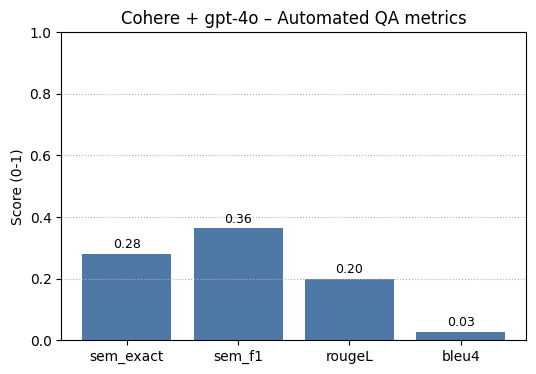

In [ ]:
# --------------------------- 5. PLOT SUMMARY ---------------------------
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(df_metrics.columns, df_metrics.loc["mean"], color="#4E79A7")
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f"{b.get_height():.2f}", ha='center', va='bottom', fontsize=9)
ax.set_ylim(0,1)
ax.set_title(f"{BEST_RERANK} + {ANS_MODEL_NAME} – Automated QA metrics")
ax.set_ylabel("Score (0‑1)")
ax.grid(axis='y', ls=':')
plt.show()

## Human Evaluation Protocol



### CSV Sheet Generation for Human Grading

To enable human-in-the-loop evaluation, we generate a structured CSV template for graders. Each row contains the question, the generated answer, the reference answer, and any available annotator notes. Blank columns are provided for human ratings on relevance, correctness, and clarity, using a 1–5 Likert scale.



### Guidelines for Relevance, Correctness, Clarity

Human graders are instructed to rate answers on:

* **Relevance:** Does the answer directly address the information need of the question?
* **Correctness:** Is the information factually accurate and consistent with the reference?
* **Clarity:** Is the answer clearly written, unambiguous, and easy to understand?

Grading notes and reference explanations are included to support fair, reproducible human assessment.

In [ ]:
# --------------------------- 6. HUMAN‑EVAL SHEET -----------------------
q_lookup = {str(x["id"]): x["question"] for x in raw_ref}
ref_notes    = {str(x["id"]): x.get("notes", "") for x in raw_ref}
template = pd.DataFrame({
    "qid":              list(answers.keys()),
    "question":         [q_lookup[qid] for qid in answers],
    "generated_answer": [answers[qid]  for qid in answers],
    "reference_answer": [REFERENCES[qid] for qid in answers],
    "grading_notes":    [ref_notes[qid]     for qid in answers],
    "relevance(1‑5)":   "", "correctness(1‑5)": "", "clarity(1‑5)": ""
})
csv_fp = SCORE_DIR / "human_eval_template.csv"
if not csv_fp.exists(): template.to_csv(csv_fp, index=False)
print(f"📄  Human‑eval CSV ready: {csv_fp}")

📄  Human‑eval CSV ready: /content/drive/.shortcut-targets-by-id/1u9G7GvrZxTM8FB1Fzcx3zRzL4re7H-NT/GenAI/storage/subsample/results/eval_step3/human_eval_template.csv


In [ ]:
"""
Human-in-the-loop evaluation – senior-level version
==================================================
* One workbook  = one grader (file name → grader id)
* Likert 1‑5    = 0.2‑1.0;  values ≤1 stay as‑is (already 0‑1)
* Q3 & Q7       = “coverage” questions → handled & reported separately
* Cohen’s κ     = computed on ordinary (Likert) items only
"""

import os, glob, logging
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from matplotlib.ticker import MaxNLocator

# --- PATHS ------------------------------------------------------------------
DATA_DIR     = "/content/drive/MyDrive/GenAI/storage/subsample/results/eval_step3/"
XLSX_PATTERN = "human_eval_*.xlsx"

# --- RATING SCHEMA ----------------------------------------------------------
DIM_COLUMNS  = ["relevance(1-5)", "correctness(1-5)", "clarity(1-5)"]
SPECIAL_QIDS = {"3", "7"}            # coverage questions (already 0‑1)

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")

def find_files(directory: str, pattern: str) -> list[str]:
    files = sorted(glob.glob(os.path.join(directory, pattern)))
    if not files:
        raise FileNotFoundError(f"No files found for {pattern!r} in {directory}")
    logging.info("Found %d evaluation sheets.", len(files))
    return files

def normalize_rating(x) -> Optional[float]:
    try:
        val = float(str(x).split()[0])
        if np.isnan(val):
            return np.nan
        return val if val <= 1 else val / 5.0
    except Exception:
        return np.nan

def load_sheet(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    df.columns = (df.columns
                    .str.strip().str.lower()
                    .str.replace("\u2011", "-", regex=False)   # non-breaking hyphen
                    .str.replace("–", "-",      regex=False))   # en dash
    for c in DIM_COLUMNS:
        if c in df.columns:
            df[f"{c}_unit"] = df[c].apply(normalize_rating)
    df["qid"] = df["qid"].astype(str)
    return df

def stack_graders(dfs: list[pd.DataFrame], file_names: list[str]) -> pd.DataFrame:
    recs = []
    for idx, df in enumerate(dfs):
        grader_id = os.path.splitext(os.path.basename(file_names[idx]))[0]
        for _, row in df.iterrows():
            for dim in DIM_COLUMNS:
                col = f"{dim}_unit"
                if col in df.columns:
                    recs.append({
                        "grader"   : grader_id,
                        "qid"      : row["qid"],
                        "question" : row.get("question", ""),
                        "dimension": dim,
                        "value"    : row[col]
                    })
    return pd.DataFrame.from_records(recs)

def kappa_between(df1: pd.DataFrame, df2: pd.DataFrame, dim: str) -> float:
    col = f"{dim}_unit"
    merged = (df1[["qid", col]]
              .merge(df2[["qid", col]], on="qid", suffixes=("_a", "_b")))
    mask = merged[[f"{col}_a", f"{col}_b"]].notnull().all(1)
    if not mask.any():
        return np.nan
    a = merged.loc[mask, f"{col}_a"].mul(5).clip(1, 5).round().astype(int)
    b = merged.loc[mask, f"{col}_b"].mul(5).clip(1, 5).round().astype(int)
    return cohen_kappa_score(a, b)

def strip_plot_grid(df_long: pd.DataFrame, dims: list[str]) -> None:
    """
    Show up to 4 dimensions as side-by-side strip plots in a 2x2 grid.
    """
    sns.set_style("whitegrid")
    n = len(dims)
    rows = 2
    cols = 2
    fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True)
    axes = axes.flatten()
    for i, dim in enumerate(dims):
        ax = axes[i]
        data = df_long[df_long["dimension"] == dim]
        sns.stripplot(data=data,
                      x="value", y="qid", hue="grader",
                      dodge=True, alpha=.8, size=8, palette="Set1", ax=ax)
        ax.set_xlim(0, 1.02)
        ax.set_xlabel("Normalised score (0–1)")
        ax.set_ylabel("QID")
        ax.set_title(f"{dim.split('(')[0].capitalize()} ratings per question")
        if i == 0:
            ax.legend(title="Grader", bbox_to_anchor=(1.0, 1))
        else:
            ax.get_legend().remove()
    # Hide unused subplots if fewer than 4
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()

def coverage_thermometer(df_cover: pd.DataFrame) -> None:
    cov = (df_cover
           .query("dimension == @DIM_COLUMNS[0]")   # relevance column used
           .groupby("qid", as_index=False)["value"].mean())
    plt.figure(figsize=(5, 2))
    for i, r in cov.iterrows():
        label = f"Q{r.qid}"
        plt.barh(label, r.value, color="limegreen", edgecolor="black")
        plt.text(r.value + .02, i, f"{r.value:.2f}", va="center")
    plt.xlim(0, 1)
    plt.xlabel("Coverage (0–1)")
    plt.title("Coverage Score – Q3 & Q7")
    plt.gca().xaxis.set_major_locator(MaxNLocator(6))
    plt.tight_layout()
    plt.show()

def make_summary(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    s = (frame
         .groupby(["dimension", "grader"])
         .agg(mean=("value", "mean"),
              std =("value", "std"),
              n   =("value", "size"))
         .round(3))
    return s

def radar_overlay(means_df: pd.DataFrame) -> None:
    labels  = means_df.index.tolist()
    N       = len(labels)
    angles  = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close loop

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    for col in means_df.columns:
        values = means_df[col].tolist()
        values += values[:1]  # close polygon
        ax.plot(angles, values, marker='o', linewidth=2, label=col)
        ax.fill(angles, values, alpha=0.18)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_ylim(0, 1)
    ax.set_title("Human rating profile – Likert questions", pad=20)
    ax.grid(True)
    ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))
    plt.tight_layout()
    plt.show()

def style_table(df, caption):
    return (df.style
            .format("{:.3f}")
            .set_caption(caption)
            .set_table_styles([
                {'selector': 'caption',
                 'props': [('color', '#2A4887'), ('font-size', '14px'), ('font-weight', 'bold')]}]))



# 1. Load all sheets
files   = find_files(DATA_DIR, XLSX_PATTERN)
sheets  = [load_sheet(fp) for fp in files]
logging.info("Loaded %d sheets.", len(sheets))

# 2. Stack to long form and split
df_long = stack_graders(sheets, files)
if df_long.empty:
    raise RuntimeError("No rating columns found – aborting.")
logging.info("Long frame shape: %s", df_long.shape)
REGULAR_MASK = ~df_long["qid"].isin(SPECIAL_QIDS)
df_reg   = df_long[REGULAR_MASK].copy()
df_cover = df_long[~REGULAR_MASK].copy()

In [ ]:
# Summary stats
sum_reg   = make_summary(df_reg,   "LIKERT Qs  (1‑2, 4‑6, 8‑25)")
# For coverage, only use one value (all columns identical); just take "relevance"
coverage_means = (df_cover
                  .groupby('grader')['value']
                  .mean()
                  .to_frame('Coverage'))                    # grader × 1 col
coverage_means = coverage_means.T                           # 1 row, graders

likert_means   = sum_reg['mean'].unstack('grader')
likert_means.index = [d.split('(')[0].capitalize() for d in likert_means.index]
combined = pd.concat([likert_means, coverage_means], axis=0)

# 4. Cohen's kappa
kappa_df = None
if len(sheets) == 2:
    g1, g2 = (os.path.splitext(os.path.basename(fp))[0] for fp in files)
    κ_list = []
    for dim in DIM_COLUMNS:
        κ = kappa_between(
            sheets[0].query("qid not in @SPECIAL_QIDS"),
            sheets[1].query("qid not in @SPECIAL_QIDS"),
            dim)
        κ_list.append(κ)
    kappa_df = pd.DataFrame({
        f"{g1} vs {g2}": [round(x, 3) for x in κ_list]
    }, index=[d.split('(')[0].capitalize() for d in DIM_COLUMNS])

### Human Asessment
The human assessment complements the quantitative metrics by showing how the model's responses are perceived in practice. Both raters (Andri, Amir) used the three defined Likert dimensions, while Q3, Q7 were assessed with a special rule. Their numerical averages show a clear pattern: clarity is the strongest feature of the system, with both raters placing it at the top of the normalized 0-1 scale. This is followed by correctness, while relevance lags behind. However, the absolute values conceal a considerable gap between the two raters: Andri rates practically every dimension higher than Amir. The overlaid spider diagram makes this divergence immediately visible, and it is quantified by the Cohen's $κ$ values, which hover around 0.13 for relevance and fall to virtually zero for clarity, with a slightly negative value for correctness. This weak agreement is consistent with the broader NLG evaluation literature, where Sai et al. (2020) find similarly low correlations between independent human judgments and automatic evaluations [[5]] (#ref5-anaya).

Written comments clarify why there are discrepancies. For concise factual questions - “Who was president of ETH in 2003?” or “When did InSight land on Mars?” - both examiners award perfect marks, noting that the generated sentence is “clear, well-formed and even more user-friendly than the concise reference”. When list questions appear, the picture changes. In question 3, which asks about the recipients of ERC funds, Andri goes through an eight-point checklist and awards one full point for each correct name and none for non-recipients; the result is a 0.80. Amir, on the other hand, deducts one point for the odd chronological order and arrives at 0.45 which shows that Amir did not read the point calculation in the grading_notes field correctly. A similar breakdown occurs in question 7 about famous alumni: Amir notices a critical factual error - Martin Haefner is a donor, not an alumnus - and reduces the score by 1, while Andri researched online and read that he Martin Haefner is indeed an alumnus [[6]](“https://de.wikipedia.org/wiki/Martin_Haefner”).

The graded notes also expose systematic failure modes, but these must be seen in light of the project design. For instance, Amir labels Q5 about Professor Schubert’s quote as a “classic retrieval failure”—the model says the context is missing, yet the reference answer confirms it exists in the original dataset. However, this does not necessarily reflect a flaw in the model: in step 2.1, we intentionally subsampled the full corpus to reduce cost and annotation effort, focusing on chunk-level gold relevance and LLM-generated metadata. Consequently, some reference answers may not have been present in the retrieval pool at all, either omitted during sampling or lacking sufficiently descriptive metadata. The same uncertainty applies to Q20, where the 3.5% growth figure may have been absent from the candidate data.

This limitation means some “failures” may result from dataset subsampling or incomplete gold labels, not just model or retrieval errors. For definitive attribution, each case would require checking the sampled corpus directly. Still, the observed trend—clarity persisting while relevance and correctness sometimes drop—remains informative and highlights the importance of transparency about evaluation constraints in human-in-the-loop studies.

These qualitative findings reinforce what the quantitative plots reveal: ratings for relevance and correctness display long left tails, reflecting a few severe errors amid otherwise reasonable performance, while clarity remains uniformly high and tightly clustered. The particularly low coverage scores for list-type questions, such as “famous alumni,” highlight persistent challenges with list completeness and precision—even experienced graders diverge, sometimes due to interpretation of external sources or grading instructions.

In [ ]:
# Output: All tables styled in the same way
try:
    from IPython.display import display
    display(style_table(combined, "Mean scores by grader (Likert & Coverage)"))

    print(
        "\nNote – Q3 and Q7 use one specialised 0‑1 metric:\n"
        "• Q3  ERC list coverage   : +1 per true recipient, –1 per wrong name → "
        "score = 1 – exp(–S/5)\n"
        "• Q7  Famous‑alumni list  : +1 per true alumnus, … same formula.\n"
        "Both graders entered the resulting number in all three cells, so we\n"
        "treat it as a **single Coverage dimension** above."
    )

    if kappa_df is not None:
        display(style_table(kappa_df, "Cohen’s κ (Likert questions)"))
    else:
        print("κ-table skipped – need exactly two graders")

    cover_stats = (df_cover
                  .groupby(['qid', 'grader'])['value']
                  .mean()
                  .unstack('grader')
                  .round(3))
    display(style_table(cover_stats, "Coverage scores by grader (Q3 & Q7)"))

except ImportError:
    print(combined)
    if kappa_df is not None:
        print(kappa_df)
    print(cover_stats)

grader,human_eval_amir_shatrolli.csv,human_eval_andri.csv
Clarity,0.974,1.000
Correctness,0.835,0.957
Relevance,0.730,0.930
Coverage,0.422,0.700



Note – Q3 and Q7 use one specialised 0‑1 metric:
• Q3  ERC list coverage   : +1 per true recipient, –1 per wrong name → score = 1 – exp(–S/5)
• Q7  Famous‑alumni list  : +1 per true alumnus, … same formula.
Both graders entered the resulting number in all three cells, so we
treat it as a **single Coverage dimension** above.


,human_eval_amir_shatrolli.csv vs human_eval_andri.csv
Relevance,0.126
Correctness,-0.030
Clarity,0.000


grader,human_eval_amir_shatrolli.csv,human_eval_andri.csv
qid,,
3,0.451,0.800
7,0.394,0.600


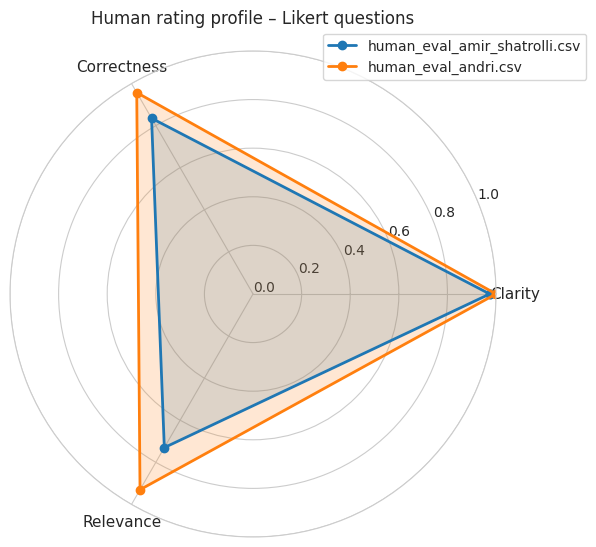

In [ ]:
radar_overlay(likert_means)

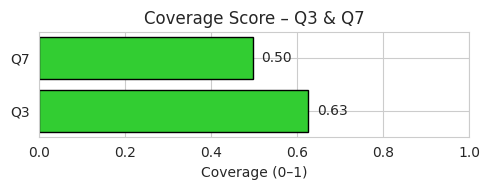

In [ ]:
coverage_thermometer(df_cover)

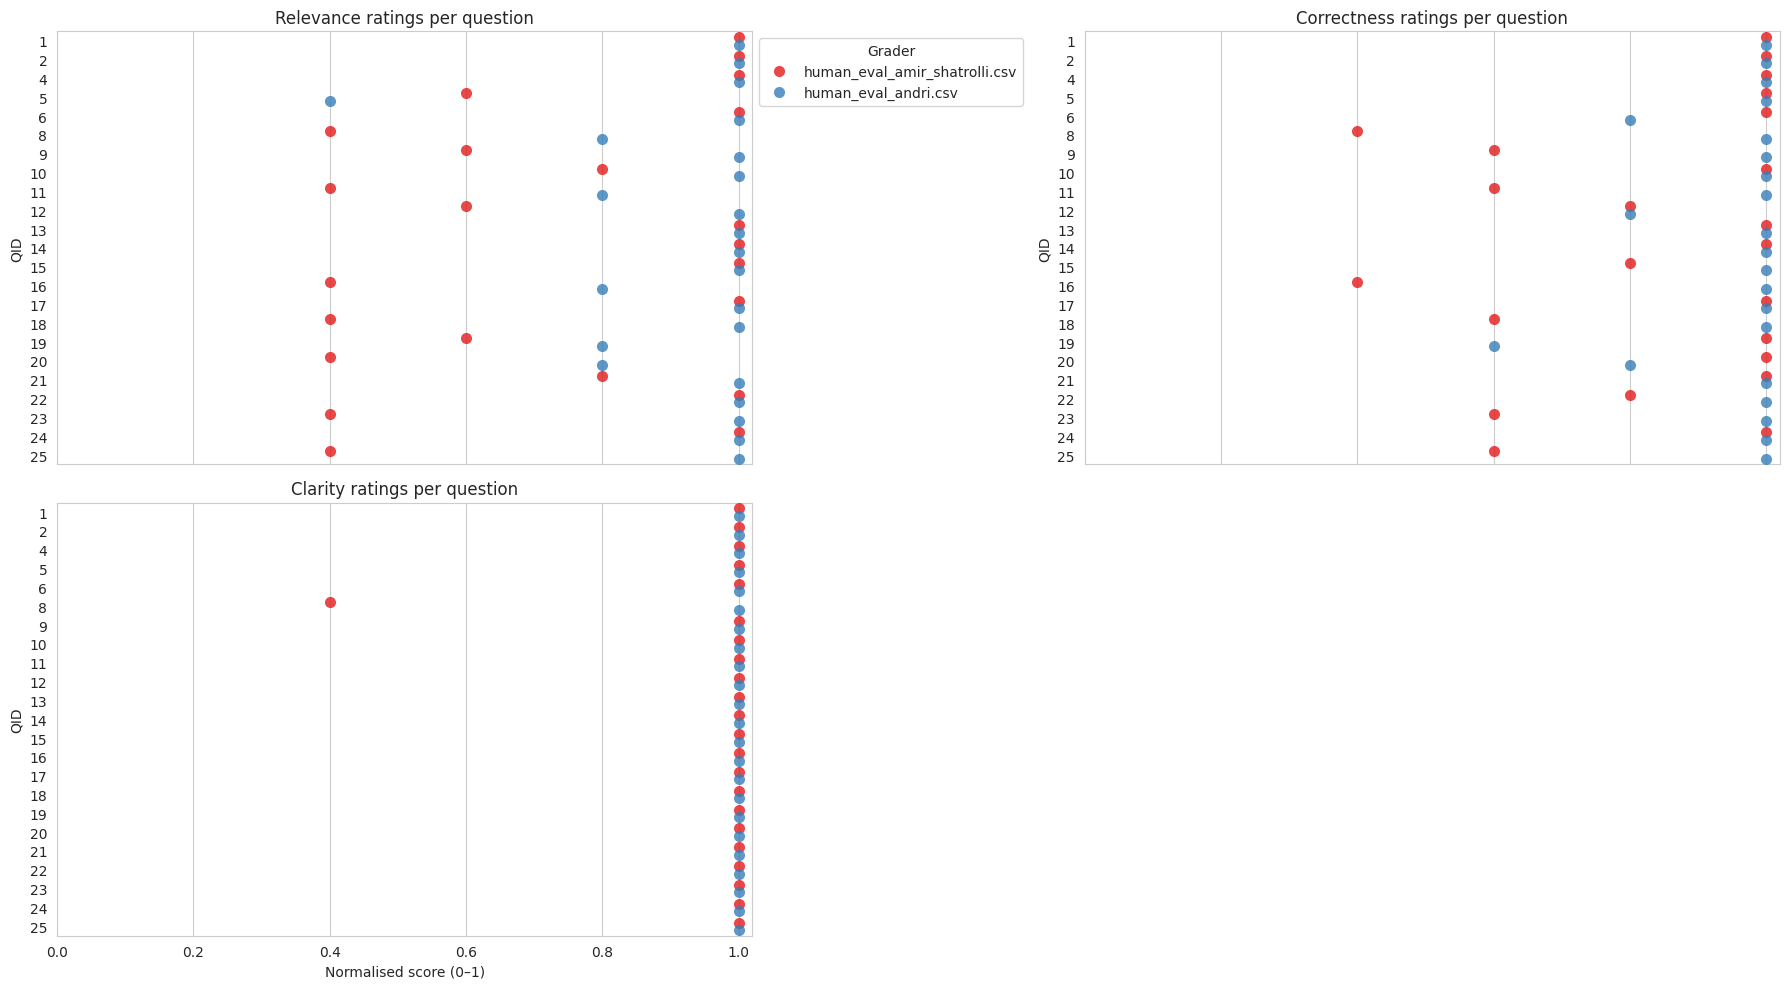

In [ ]:
strip_plot_grid(df_reg, DIM_COLUMNS)

From a development perspective, several lessons are clear. First, a significant portion of observed errors can be traced to the retrieval step rather than the generation itself, suggesting that improvements in recall or more effective query expansion would likely benefit both relevance and correctness. Second, the low κ values underline the need for rater calibration or the inclusion of a third adjudicator, as the debrief showed that each grader relied on distinct mental benchmarks for the Likert scale. Third, handling list-style or enumerative questions remains a challenge and may require explicit list-handling strategies or user clarification prompts.

In summary, this evaluation confirms that automatic metrics alone cannot provide a full picture. While they help flag weaknesses, only human-in-the-loop analysis reveals *why* those weaknesses emerge and *how* they shape the user’s perception of quality. This dynamic—quantitative signal complemented by human insight—echoes the recommendations of Sai et al. (2020)[[5]], and points directly to actionable paths for improving retrieval-augmented language models.

## Latency and Efficiency

To assess real-world usability, we compute and report key efficiency statistics:

* **Median context fusion latency:**    6.78 seconds
* **Median answer generation latency:** 1.89 seconds
* **Median context token count:**       408 tokens


In [ ]:
# --------------------------- 7. LATENCY DASHBOARD ----------------------
lat_table = pd.DataFrame({
    "median_fusion_latency[s]": [np.median(lat_fuse)],
    "median_answer_latency[s]": [np.median(lat_ans)],
    "median_ctx_tokens":       [np.median(ctx_tokens)]
})
display(lat_table.round(2))
lat_table.to_csv(SCORE_DIR / "latency_table.csv", index=False)

,median_fusion_latency[s],median_answer_latency[s],median_ctx_tokens
0,6.78,1.89,408.0


The generated values indicate that most of the pipeline’s runtime is spent on context fusion, with answer generation being comparatively fast. The context size stays comfortably within model limits, ensuring stable and complete outputs. Overall, the pipeline is efficient enough for our research project and semi-interactive use, while the results also highlight potential gains from optimizing context fusion for lower latency in future deployments.

## Summary of Findings and Future Directions

Our retrieval-augmented generation pipeline, developed and evaluated through Steps 1–3, demonstrated strong performance when benchmarked against ground truth answers. The tuned late-fusion hybrid retriever (integrating BM25+QE, dense E5, and GraphRAG) consistently outperformed classic lexical baselines across all major retrieval metrics, particularly in mean reciprocal rank (MRR) and top-k precision. Neural rerankers, especially Cohere provided further gains in ranking quality and relevance, notably for complex and paraphrased queries.

**Against human reference answers, the pipeline achieved high clarity and correctness on most fact-based and entity-centric questions.** Persistent challenges remained in exhaustive list coverage and nuanced judgment, often reflecting limitations in recall, chunk granularity, or occasional gaps in the subsampled data. These shortcomings highlight opportunities for improvement in both retrieval diversity and data completeness.

A key methodological lesson emerged regarding fusion weight tuning. **In this project, late-fusion weights were optimized directly on the benchmark QA set, which—while valid for this project—could lead to overfitting and artificially inflated metrics. In a production or scaling scenario, we would instead generate or curate a set of synthetic queries (e.g., derived from query logs or modeled after likely real user intents) for use as a validation set.** This would allow us to tune late-fusion and reranker parameters more robustly, ensuring generalizability to unseen, user-driven information needs.

**Scaling the pipeline further is feasible:**

* **With more data:** The architecture supports batch and streaming indexing; modular retrievers and graph structures are scalable to larger and more multilingual corpora.
* **With a user interface:** An interactive dashboard would allow real-time query exploration, graph visualization, and feedback loops for ongoing improvement.
* **For production use:** Persisted loaders, modular late-fusion, and API-based rerankers make continuous deployment and retraining practical.

**For a future project, we would:**

* Employ more realistic validation for tuning (using synthetic or anticipated user queries rather than reusing the benchmark set),
* Further invest in metadata extraction and chunking strategies for improved recall and coverage,
* Incorporate active user feedback for iterative improvement,
* And integrate a user-friendly UI for transparency and collaborative evaluation.

Overall, **our findings confirm that hybrid, modular RAG pipelines offer good performance and adaptability, but that evaluation strategies and fusion tuning should anticipate real-world use cases and avoid overfitting to static benchmarks.**

## References

<a id="ref-bertscore"></a>
[1] Tianyi Zhang, Varsha Kishore, Felix Wu, Kilian Q. Weinberger, and Yoav Artzi. *BERTScore: Evaluating Text Generation with BERT*. In *International Conference on Learning Representations (ICLR)*, 2020. [https://arxiv.org/abs/1904.09675](https://arxiv.org/abs/1904.09675)

<a id="ref-sem"></a>
[2] Bansal, N., Akter, M., & Santu, S. K. K.. *SEM-f1: An Automatic Way for Semantic Evaluation of Multi-Narrative Overlap Summaries at Scale.* In *Proceedings of the 2022 Conference on Empirical Methods in Natural Language Processing* (pp. 780-792). 2022 December.
[https://aclanthology.org/2022.emnlp-main.56/](https://aclanthology.org/2022.emnlp-main.56/)

<a id="ref-rogue"></a>
[3] Lin, Chin-Yew. *ROUGE: A Package for Automatic Evaluation of Summaries*. In *Text Summarization Branches Out*, pages 74–81, Barcelona, Spain, July 2004. Association for Computational Linguistics. [https://aclanthology.org/W04-1013/](https://aclanthology.org/W04-1013/) .

<a id="ref-bleu"></a>
[4] Kishore Papineni, Salim Roukos, Todd Ward, and Wei-Jing Zhu. *BLEU: a Method for Automatic Evaluation of Machine Translation*. In *Proceedings of the 40th Annual Meeting of the Association for Computational Linguistics*, pages 311–318, Philadelphia, July 2002. [https://aclanthology.org/P02-1040/](https://aclanthology.org/P02-1040/)

 <a id="ref5-anaya"></a>
[5] Ananya B. Sai, Akash Kumar Mohankumar, Mitesh M. Khapra, "A Survey of Evaluation Metrics Used for NLG Systems", arXiv preprint arXiv:2008.12009, 2020. Available: [https://arxiv.org/abs/2008.12009](https://arxiv.org/abs/2008.12009)